In [1]:
import warnings
warnings.filterwarnings("ignore")

import hashlib
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import average_precision_score, precision_recall_curve, confusion_matrix, precision_score, recall_score

BASELINE_PATH = "../padme/src/main/resources/data/baseline_latest.csv"
PADME_PATH = "../padme/src/main/resources/data/padme_latest.csv"
TEST_PATH = "../padme/src/main/resources/data/unsw_nb15_test.csv"

TARGET_COL = "label"
RANDOM_STATE = 42

In [2]:
baseline = pd.read_csv(BASELINE_PATH)
padme = pd.read_csv(PADME_PATH)
test = pd.read_csv(TEST_PATH)

print("Baseline rows (raw):", len(baseline))
print("PADME rows (raw):", len(padme))
print("Test rows:", len(test))

baseline = baseline.drop_duplicates().reset_index(drop=True)
padme = padme.drop_duplicates().reset_index(drop=True)

print("\nBaseline rows (unique):", len(baseline))
print("PADME rows (unique):", len(padme))

Baseline rows (raw): 100000
PADME rows (raw): 5000
Test rows: 5000

Baseline rows (unique): 20000
PADME rows (unique): 2731


In [3]:
def balance(df):
    c = df[TARGET_COL].value_counts().sort_index()
    r = df[TARGET_COL].value_counts(normalize=True).sort_index()
    return c, r

for name, df in [("BASELINE", baseline), ("PADME", padme), ("TEST", test)]:
    c, r = balance(df)
    print("\n" + name)
    print("Counts:", c.to_dict())
    print("Ratio :", {int(k): float(v) for k, v in r.to_dict().items()})



BASELINE
Counts: {0: 16000, 1: 4000}
Ratio : {0: 0.8, 1: 0.2}

PADME
Counts: {0: 2140, 1: 591}
Ratio : {0: 0.7835957524716222, 1: 0.2164042475283779}

TEST
Counts: {0: 1597, 1: 3403}
Ratio : {0: 0.3194, 1: 0.6806}


In [4]:
DROP_COLS = ["__id", "label", "attack_cat", "proto", "service", "state"]

def split_xy(df):
    drop_cols = [c for c in DROP_COLS if c in df.columns]
    X = df.drop(columns=drop_cols)
    y = df[TARGET_COL]
    return X, y

Xb, yb = split_xy(baseline)
Xp, yp = split_xy(padme)
Xt, yt = split_xy(test)

In [5]:
def choose_threshold(model_ctor, X, y, recall_target=0.85, n_splits=10, random_state=42):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    oof_probs = np.zeros(len(y), dtype=float)

    for tr_idx, va_idx in skf.split(X, y):
        m = model_ctor()
        m.fit(X.iloc[tr_idx], y.iloc[tr_idx])
        oof_probs[va_idx] = m.predict_proba(X.iloc[va_idx])[:, 1]

    precision, recall, thresholds = precision_recall_curve(y, oof_probs)

    precision = precision[:-1]
    recall = recall[:-1]

    eligible = np.where(recall >= recall_target)[0]
    if len(eligible) == 0:
        best_idx = int(np.argmax(recall))
        return float(thresholds[best_idx]), float(recall[best_idx]), float(precision[best_idx])

    best_idx = int(eligible[np.argmax(precision[eligible])])
    return float(thresholds[best_idx]), float(recall[best_idx]), float(precision[best_idx])

In [6]:
def lr_ctor():
    return LogisticRegression(max_iter=1000, solver="lbfgs", class_weight="balanced", random_state=RANDOM_STATE)

def et_ctor():
    return ExtraTreesClassifier(n_estimators=400, random_state=RANDOM_STATE, n_jobs=-1, class_weight="balanced")

thr_lr, achieved_recall_lr, achieved_precision_lr = choose_threshold(lr_ctor, Xb, yb, recall_target=0.85, n_splits=5, random_state=RANDOM_STATE)
thr_et, achieved_recall_et, achieved_precision_et = choose_threshold(et_ctor, Xb, yb, recall_target=0.85, n_splits=5, random_state=RANDOM_STATE)

print("Chosen threshold - LR:", thr_lr)
print("Achieved recall - LR:", achieved_recall_lr)
print("Achieved precision - LR:", achieved_precision_lr)

print("\nChosen threshold - ET:", thr_et)
print("Achieved recall - ET:", achieved_recall_et)
print("Achieved precision - ET:", achieved_precision_et)

Chosen threshold - LR: 0.5006393869770682
Achieved recall - LR: 0.85075
Achieved precision - LR: 0.474484104852203

Chosen threshold - ET: 0.5
Achieved recall - ET: 0.85
Achieved precision - ET: 0.899947061937533


In [7]:
lr_b = lr_ctor()
lr_p = lr_ctor()
lr_b.fit(Xb, yb)
lr_p.fit(Xp, yp)

et_b = et_ctor()
et_p = et_ctor()
et_b.fit(Xb, yb)
et_p.fit(Xp, yp)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",400
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=FalseWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",False
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metr

In [8]:
HASH_IGNORE = ["__id", "label", "attack_cat", "proto", "service", "state"]

def row_hash_series(df, cols=None):
    if cols is None:
        cols = [c for c in df.columns if c not in HASH_IGNORE]
    cols = [c for c in cols if c in df.columns]
    s = df[cols].astype("string").fillna("").agg("|".join, axis=1)
    return s.apply(lambda x: hashlib.sha1(x.encode("utf-8")).hexdigest())

def row_overlap(df_a, df_b):
    ha = row_hash_series(df_a)
    hb = row_hash_series(df_b)
    hb_set = set(hb)
    inter_a_in_b = int(ha.isin(hb_set).sum())
    overlap_a = inter_a_in_b / len(df_a) if len(df_a) else 0.0

    ha_set = set(ha)
    inter_b_in_a = int(hb.isin(ha_set).sum())
    overlap_b = inter_b_in_a / len(df_b) if len(df_b) else 0.0

    return inter_a_in_b, overlap_a, inter_b_in_a, overlap_b

k = len(padme)
seeds = [101, 102, 103]

random_models_lr = []
random_models_et = []

for s in seeds:
    rdf = baseline.sample(n=k, random_state=s)

    inter_ab, ov_a, inter_ba, ov_b = row_overlap(rdf, padme)
    print(f"seed={s}  random_in_padme={inter_ab}/{len(rdf)}={ov_a:.4f}  padme_in_random={inter_ba}/{len(padme)}={ov_b:.4f}")

    Xr, yr = split_xy(rdf)

    m_lr = lr_ctor()
    m_lr.fit(Xr, yr)
    random_models_lr.append(m_lr)

    m_et = et_ctor()
    m_et.fit(Xr, yr)
    random_models_et.append(m_et)

seed=101  random_in_padme=480/2731=0.1758  padme_in_random=395/2731=0.1446
seed=102  random_in_padme=533/2731=0.1952  padme_in_random=466/2731=0.1706
seed=103  random_in_padme=510/2731=0.1867  padme_in_random=441/2731=0.1615


In [9]:
def eval(model, Xt, yt, threshold):
    probs = model.predict_proba(Xt)[:, 1]
    pr_auc = average_precision_score(yt, probs)
    preds = (probs >= threshold).astype(int)
    return {
        "pr_auc": float(pr_auc),
        "threshold": float(threshold),
        "precision": float(precision_score(yt, preds, zero_division=0)),
        "recall": float(recall_score(yt, preds, zero_division=0)),
        "confusion_matrix": confusion_matrix(yt, preds)
    }

In [10]:
results = {
    "baseline_lr": eval(lr_b, Xt, yt, thr_lr),
    "padme_lr": eval(lr_p, Xt, yt, thr_lr),
    "baseline_et": eval(et_b, Xt, yt, thr_et),
    "padme_et": eval(et_p, Xt, yt, thr_et)
}

random_results_lr = []
for s, m in zip(seeds, random_models_lr):
    r = eval(m, Xt, yt, thr_lr)
    r["seed"] = s
    random_results_lr.append(r)

random_results_et = []
for s, m in zip(seeds, random_models_et):
    r = eval(m, Xt, yt, thr_et)
    r["seed"] = s
    random_results_et.append(r)

def print_block(title, res):
    print("\n" + title)
    print("pr_auc:", res["pr_auc"])
    print("threshold:", res["threshold"])
    print("precision:", res["precision"])
    print("recall:", res["recall"])
    print("confusion_matrix:\n", res["confusion_matrix"])

print_block("baseline_lr", results["baseline_lr"])
print_block("padme_lr", results["padme_lr"])

pr_aucs = np.array([r["pr_auc"] for r in random_results_lr], dtype=float)
precisions = np.array([r["precision"] for r in random_results_lr], dtype=float)
recalls = np.array([r["recall"] for r in random_results_lr], dtype=float)

print("\nrandom_k_lr summary (mean ± std)")
print("pr_auc:", float(pr_aucs.mean()), "±", float(pr_aucs.std(ddof=1)))
print("precision:", float(precisions.mean()), "±", float(precisions.std(ddof=1)))
print("recall:", float(recalls.mean()), "±", float(recalls.std(ddof=1)))

print_block("baseline_et", results["baseline_et"])
print_block("padme_et", results["padme_et"])

pr_aucs = np.array([r["pr_auc"] for r in random_results_et], dtype=float)
precisions = np.array([r["precision"] for r in random_results_et], dtype=float)
recalls = np.array([r["recall"] for r in random_results_et], dtype=float)

print("\nrandom_k_et summary (mean ± std)")
print("pr_auc:", float(pr_aucs.mean()), "±", float(pr_aucs.std(ddof=1)))
print("precision:", float(precisions.mean()), "±", float(precisions.std(ddof=1)))
print("recall:", float(recalls.mean()), "±", float(recalls.std(ddof=1)))


baseline_lr
pr_auc: 0.919476519364285
threshold: 0.5006393869770682
precision: 0.8778793418647166
recall: 0.7055539230091096
confusion_matrix:
 [[1263  334]
 [1002 2401]]

padme_lr
pr_auc: 0.8952657375245
threshold: 0.5006393869770682
precision: 0.8341026337225088
recall: 0.9027328827505142
confusion_matrix:
 [[ 986  611]
 [ 331 3072]]

random_k_lr summary (mean ± std)
pr_auc: 0.9165014220697522 ± 0.004038531492727376
precision: 0.8843725202654342 ± 0.013294310497632111
recall: 0.6716622587912626 ± 0.07177386430409154

baseline_et
pr_auc: 0.9860188781155872
threshold: 0.5
precision: 0.9914761720263464
recall: 0.7519835439318249
confusion_matrix:
 [[1575   22]
 [ 844 2559]]

padme_et
pr_auc: 0.9848743145439234
threshold: 0.5
precision: 0.9856057576969213
recall: 0.724360858066412
confusion_matrix:
 [[1561   36]
 [ 938 2465]]

random_k_et summary (mean ± std)
pr_auc: 0.9823544552353539 ± 0.0006398504138594068
precision: 0.9882560293804706 ± 0.0013788941665533196
recall: 0.67626603976883

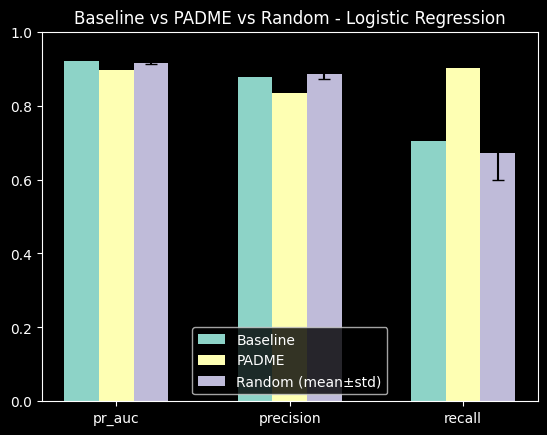

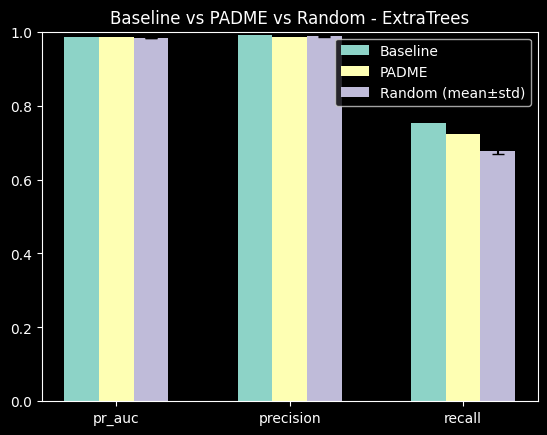

In [11]:
metrics = ["pr_auc", "precision", "recall"]
x = np.arange(len(metrics))
width = 0.20

baseline_values = [results["baseline_lr"][m] for m in metrics]
padme_values = [results["padme_lr"][m] for m in metrics]
random_mean = [float(np.mean([r[m] for r in random_results_lr])) for m in metrics]
random_std = [float(np.std([r[m] for r in random_results_lr], ddof=1)) for m in metrics]

plt.figure()
plt.bar(x - width, baseline_values, width, label="Baseline")
plt.bar(x, padme_values, width, label="PADME")
plt.bar(x + width, random_mean, width, yerr=random_std, capsize=4, label="Random (mean±std)")
plt.xticks(x, metrics)
plt.ylim(0, 1)
plt.legend()
plt.title("Baseline vs PADME vs Random - Logistic Regression")
plt.show()

baseline_values = [results["baseline_et"][m] for m in metrics]
padme_values = [results["padme_et"][m] for m in metrics]
random_mean = [float(np.mean([r[m] for r in random_results_et])) for m in metrics]
random_std = [float(np.std([r[m] for r in random_results_et], ddof=1)) for m in metrics]

plt.figure()
plt.bar(x - width, baseline_values, width, label="Baseline")
plt.bar(x, padme_values, width, label="PADME")
plt.bar(x + width, random_mean, width, yerr=random_std, capsize=4, label="Random (mean±std)")
plt.xticks(x, metrics)
plt.ylim(0, 1)
plt.legend()
plt.title("Baseline vs PADME vs Random - ExtraTrees")
plt.show()